<a href="https://colab.research.google.com/github/EvalynTheAnalyst/facial_recognition_analysis/blob/evalyn/Copy_of_human_emotion_detection6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Title: Facial Emotion Recognition for Mental Wellness Monitoring
### Goal:
 Build and deploy a system that detects human emotions (e.g. happy, sad, angry, neutral) from facial images to help mental health apps understand users’ emotional states in real time.

### Why this matters:
 Emotional monitoring can help improve chatbot responses, tailor wellness content, and alert when users show signs of distress.


#DATA COLLECTION AND ANOTATION


# Copying images to my drive

## Save into drive

In [5]:
import os
import pathlib
import json
from google.colab import files
import cv2
import shutil

#downloading kaggle
!pip install -q kaggle

from google.colab import userdata
user = userdata.get('username')
api_key = userdata.get('key')

os.environ['KAGGLE_USERNAME'] = user
os.environ['KAGGLE_KEY'] = api_key

username,api_key = json.dumps(user),json.dumps(api_key) # put a python object to a json string


In [6]:

!kaggle datasets download -d dollyprajapati182/balanced-affectnet

#!unzip dollyprajapati182/balanced-affectnet

Dataset URL: https://www.kaggle.com/datasets/dollyprajapati182/balanced-affectnet
License(s): unknown
balanced-affectnet.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip balanced-affectnet.zip

In [8]:
# # # copy images to my drive
# import shutil

# # # Create a directory in your Google Drive
# !mkdir -p /content/drive/MyDrive

# # # Copy the  folder
# shutil.copytree("final_dataset", "/content/drive/MyDrive/facial_dataset", dirs_exist_ok=True)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam,SGD
from sklearn.model_selection import StratifiedKFold
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
#count images per class
import os
from collections import defaultdict

#Dataset path
train_path = "/content/train"

# Create a function that counts the total number of emotions in a class

def count_emotions(directory):
    emotion_counts = defaultdict(int)
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith((".jpg", ".png")):
                emotion = os.path.basename(root)
                emotion_counts[emotion] += 1
    return emotion_counts

count_emotions(train_path)

defaultdict(int,
            {'Sad': 2867,
             'Happy': 3690,
             'Surprise': 3690,
             'Fear': 3690,
             'Anger': 3690,
             'Contempt': 3690,
             'Disgust': 3690,
             'Neutral': 3690})

In [12]:
train_path = '/content/train'

# # Make sure you have PIL installed (comes by default in Colab)
# from PIL import Image


# # Counter to track what we do
# total_checked = 0
# corrupted_found = 0

# print(f"Scanning images inside: {train_path}\n")

# for root, dirs, files in os.walk(train_path):
#     for fname in files:
#         if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
#             fpath = os.path.join(root, fname)
#             total_checked += 1
#             try:
#                 img = Image.open(fpath)
#                 img.verify()  # Quick check to see if it can be opened properly
#             except Exception as e:
#                 print(f"Removing corrupted image: {fpath}")
#                 os.remove(fpath)
#                 corrupted_found += 1

# print(" Done!")
# print(f"Total images checked: {total_checked}")
# print(f"Corrupted images removed: {corrupted_found}")




In [13]:
test_path = '/content/test'

# for root, dirs, files in os.walk(test_path):
#   for file in files:
#     print(os.path.join(root,file))


In [14]:
val_path = '/content/val'

# for root, dirs, files in os.walk(val_path):
#   for file in files:
#     print(os.path.join(root,file))

In [15]:
#2. Data Preprocessing & Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,            # slightly higher rotation
    width_shift_range=0.15,       # shift up to 15%
    height_shift_range=0.15,      # shift up to 15%
    zoom_range=0.2,               # zoom in/out up to 20%
    shear_range=10,               # slight shear
    horizontal_flip=True,
    fill_mode='nearest'           # avoid empty pixels after transform
)

In [16]:
test_datagen = ImageDataGenerator(
    rescale =1./255)

In [17]:
val_datagen = ImageDataGenerator(
    rescale =1./255,
    )

In [18]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse',
    shuffle = True
)

Found 28697 images belonging to 8 classes.


In [19]:
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse',
    shuffle = True
)

Found 7325 images belonging to 8 classes.


In [20]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse'
)

Found 4085 images belonging to 8 classes.


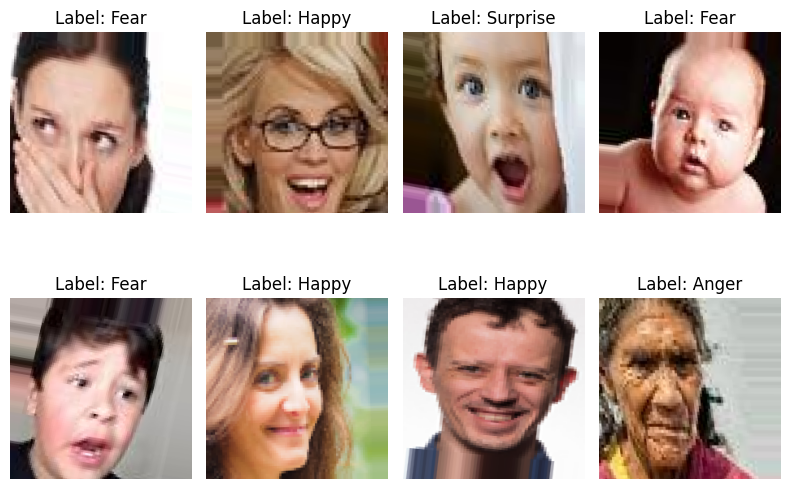

In [21]:
#first 8 images
image, label = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(8,6))
for i in range(8):
   plt.subplot(2, 4, i+1)
   plt.imshow(image[i])
   label_index = int(label[i])  # directly use integer label
   plt.title(f"Label: {class_names[label_index]}")
   plt.axis("off")
plt.tight_layout()
plt.show()

## EarlyStopping


In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience =3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
    ]


## modelcompile



In [24]:
# model.compile(
#     loss = 'sparse_categorical_crossentropy',
#     optimizer = Adam(learning_rate=0.0001),
#     metrics = ['accuracy']
# )

In [25]:
#model.fit(train_data,validation_data=val_data, epochs = 50, callbacks=callbacks)

In [ ]:
from tensorflow.keras.applications import MobileNetV2,ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base =ResNet50V2(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

# Unfreeze last 20 layers for fine-tuning
for layer in base.layers[:-20]:
    layer.trainable = False
for layer in base.layers[-20:]:
    layer.trainable = True

optimizer = Adam(learning_rate=1e-4)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

history = model.fit(train_data, validation_data=val_data, epochs=50,callbacks=callbacks)

loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc}")

pred = model.predict(test_data)


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
164/897 ━━━━━━━━━━━━━━━━━━━━ 1:26:16 7s/step - accuracy: 0.2316 - loss: 1.9388

In [ ]:
model.summary()

In [ ]:
#plotting the loss and accuracy
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.plot(history.history["loss"], label ="Loss")
plt.plot(history.history["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(2,2,2)
plt.plot(history.history['accuracy'],label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import gradio as gr

# Replace with your actual class names
class_names = ['Angry', 'Happy', 'Sad', 'Surprise', 'Neutral','disgust']

def pred(img):
    img_resized = image.smart_resize(img, (224, 224))
    img_rescaled = img_resized / 255.0
    img_batch = np.expand_dims(img_rescaled, axis=0)
    preds = model.predict(img_batch)
    result = {class_names[i]: float(preds[0][i]) for i in range(len(class_names))}
    return result

iface = gr.Interface(
    fn=preds,
    inputs=gr.Image(type="numpy", label="Upload Face Image"),
    outputs=gr.Label(num_top_classes=6),
    title="Facial Emotion Recognition",
    description="Upload an image of a face to predict the emotion."
)

iface.launch(debug=True)
